# Actividad práctica: Segmentación de clientes mediante clustering

En esta actividad se trabajará con un conjunto de datos de clientes con el objetivo de identificar segmentos con características similares mediante técnicas de agrupamiento.

La segmentación se construirá utilizando **edad** e **ingreso anual**, dos variables cuantitativas que permiten trabajar directamente con distancias y visualizar los resultados en dos dimensiones. Las demás variables del conjunto de datos se utilizarán posteriormente para **caracterizar e interpretar** los grupos encontrados.

Se aplicarán dos métodos vistos en la unidad:

- K-Means.
- Agrupamiento jerárquico aglomerativo.

Para evaluar las soluciones se utilizarán la inercia o WCSS, el método del codo y el índice de silueta.

> ## **Se espera como entrega**

> Esta Notebook resuelta con el agregado del grupo al final del nombre
> Ejemplo Actividad_Clustering_Segmentacion_clientes_grupo_X.ipynb (reemplazar X por el número del grupo)


## Descripción del conjunto de datos

El siguiente conjunto de datos consiste en información sobre el comportamiento de compra de 2,000 individuos de una determinada área al entrar en una tienda física de bienes de consumo rápido. Todos los datos se han recopilado a través de las tarjetas que utilizan al momento de pagar. Los datos han sido preprocesados y no hay valores faltantes. Además, el volumen del conjunto de datos se ha limitado y anonimizado para proteger la privacidad de los clientes.

Columnas del conjunto de datos:

- **Sex**: género.  
  0: masculino,  
  1: femenino.
- **Marital status**: estado civil de un cliente.  
  0: soltero,  
  1: no soltero (divorciado/separado/casado/viudo).
- **Age**: edad del cliente en años. Valor mínimo: 18, valor máximo: 78.
- **Education**: nivel educativo del cliente.  
  0: otro/desconocido,  
  1: escuela secundaria,  
  2: universidad,  
  3: posgrado.
- **Income**: ingreso anual autoreportado en dólares estadounidenses del cliente. Valor mínimo: 35,832, valor máximo: 309,364.
- **Occupation**: categoría de la ocupación del cliente.  
  0: desempleado/no calificado,  
  1: empleado calificado/funcionario,  
  2: administración/autónomo/empleado altamente calificado/oficial.
- **Settlement size**: tamaño de la ciudad donde vive el cliente.  
  0: ciudad pequeña,  
  1: ciudad mediana,  
  2: gran ciudad.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

ModuleNotFoundError: No module named 'scipy'

### 1. Exploración inicial

Antes de aplicar un algoritmo de clustering, analice la estructura del conjunto de datos `customer_data.csv` y analice las variables `Age` e `Income` mediante estadísticos descriptivos. Represente gráficamente la relación entre edad e ingreso.

¿Se observan grupos claramente separados a simple vista en el plano edad-ingreso?

In [3]:
df_customer = pd.read_csv("./data/customer_data.csv")

display(df_customer[['Age','Income']].describe())

,Age,Income
count,2000.000000,2000.000000
mean,35.909000,120954.419000
std,11.719402,38108.824679
min,18.000000,35832.000000
25%,27.000000,97663.250000
50%,33.000000,115548.500000
75%,42.000000,138072.250000
max,76.000000,309364.000000


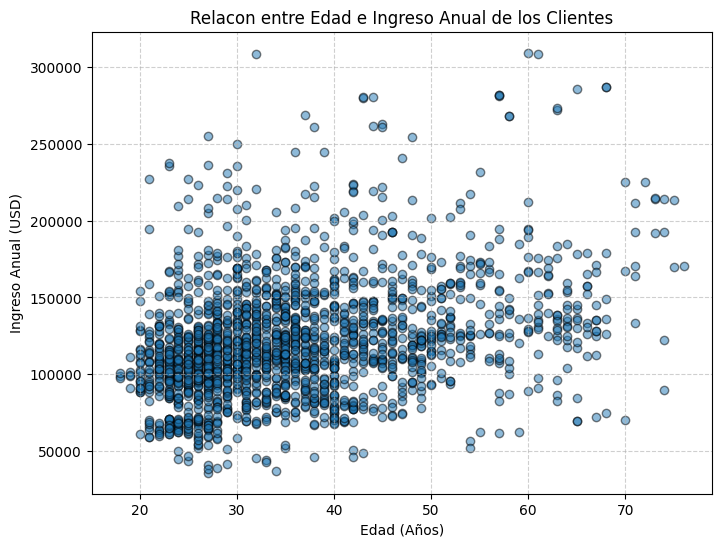

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(df_customer['Age'], df_customer['Income'], alpha=0.5, edgecolors='k')
plt.title("Relacon entre Edad e Ingreso Anual de los Clientes")
plt.xlabel('Edad (Años)')
plt.ylabel('Ingreso Anual (USD)')
plt.grid(True, linestyle='--', alpha= 0.6)
plt.show()

Al observar los estadísticos descriptivos, se evidencia una enorme diferencia de magnitudes: la edad varía en el orden de las decenas (18 a 76 años), mientras que el ingreso anual varía en el orden de los miles (35,832 a 309,364 USD). 

En el gráfico de dispersión inicial, los puntos no muestran grupos claramente separados a simple vista, se percibe como una nube de datos continua debido a que la escala del ingreso comprime visualmente el impacto de la edad.

### 2. Selección de características y escalado

Para construir los clusters se utilizarán únicamente:

$$
X = [\text{Age},\text{Income}]
$$

Las demás variables se reservarán para describir los segmentos una vez obtenidos.

In [5]:
X = df_customer[['Age', 'Income']]
display(X.head())

,Age,Income
0,67,124670
1,22,150773
2,49,89210
3,45,171565
4,53,149031


In [6]:
scaler= StandardScaler()
X_scaled = scaler.fit_transform(X)

df_X_scaled =pd.DataFrame(X_scaled, columns=['Age', 'Income'])
display(df_X_scaled.head())

NameError: name 'StandardScaler' is not defined

Es un paso metodológico estricto escalar los atributos numéricos porque algoritmos como K-Means basan sus agrupamientos en el cálculo de distancias matemáticas. Si no se aplicara una estandarización (con StandardScaler), la variable de ingreso dominaría completamente el cálculo por ser miles de veces mayor que la edad, provocando clústeres erróneos.

### 3. Selección del número de clusters con K-Means

No se conoce de antemano cuántos grupos existen en los datos.

1. Ajuste K-Means para valores de $K$ entre 1 y 10.
2. Registre la inercia o WCSS para cada valor de $K$.
3. Para $K \geq 2$, calcule además el coeficiente de silueta promedio.
4. Represente:
   - WCSS en función de $K$.
   - coeficiente de silueta promedio en función de $K$.
5. Identifique los valores de $K$ que considera más razonables y justifique.

4000.000000000001
2260.2036982510554
1647.554007199052
1281.1446885575544
1024.2393576285042
865.9055700409172
751.3055719518176
665.0294823522927
582.92900454984
511.2343383843525


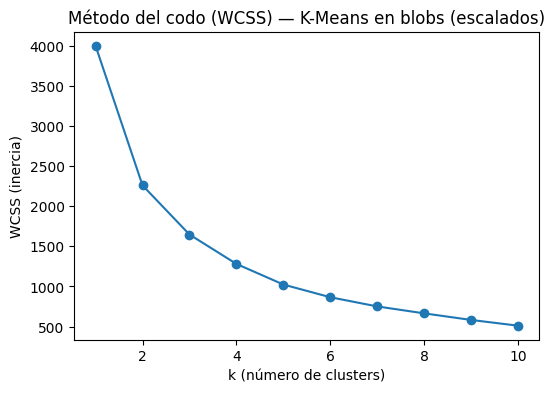

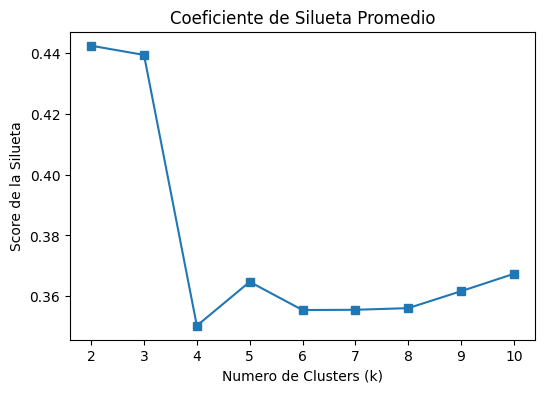

In [ ]:
K_range = range(1, 11)
wcss = []
siluetas=[]
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    wcss.append(km.inertia_)
    if k >=2:
        score= silhouette_score(X_scaled, km.labels_)
        siluetas.append(score)

for i in wcss:
    print(i)
plt.figure(figsize=(6, 4))
plt.plot(list(K_range), wcss, marker="o")
plt.title("Método del codo (WCSS) — K-Means en blobs (escalados)")
plt.xlabel("k (número de clusters)"); plt.ylabel("WCSS (inercia)")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(2,11), siluetas, marker="s")
plt.title("Coeficiente de Silueta Promedio")
plt.xlabel("Numero de Clusters (k)"); plt.ylabel("Score de la Silueta")
plt.show()

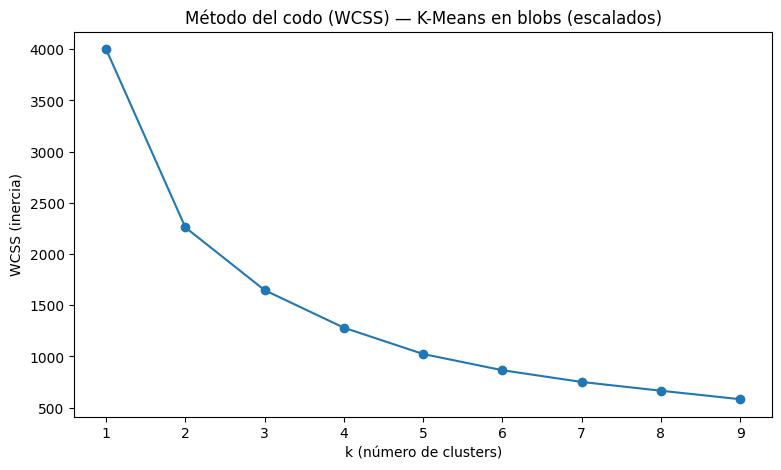

In [ ]:
# --- Método del codo en datos escalados ---
kmeans_per_k = [ KMeans(n_clusters=k, n_init=10, random_state=1).fit(X_scaled) for k in range(1, 10) ]
wcss_per_k = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(9, 5))
plt.plot(list(range(1, 10)), wcss_per_k, marker="o")
plt.title("Método del codo (WCSS) — K-Means en blobs (escalados)")
plt.xlabel("k (número de clusters)"); plt.ylabel("WCSS (inercia)")
plt.show()


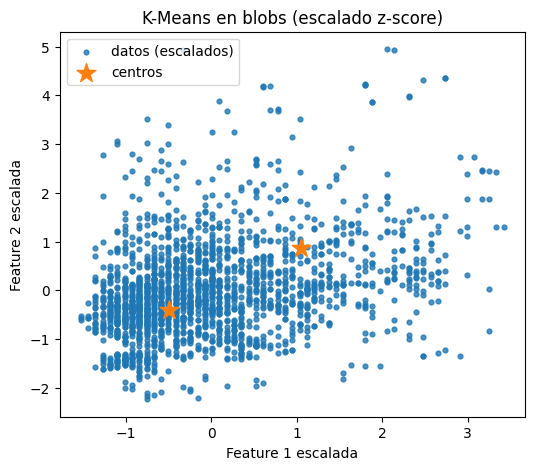

Inercia (WCSS) con escalado: 2260.2036982510554


In [ ]:
kmeans_scaled = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=12, alpha=0.8, label="datos (escalados)")
centers_scaled = kmeans_scaled.cluster_centers_
plt.scatter(centers_scaled[:, 0], centers_scaled[:, 1], marker="*", s=200, label="centros")
plt.title("K-Means en blobs (escalado z-score)")
plt.xlabel("Feature 1 escalada"); plt.ylabel("Feature 2 escalada")
plt.legend()
plt.show()

print("Inercia (WCSS) con escalado:", kmeans_scaled.inertia_)

### 4. Análisis de los diagramas de silueta

El coeficiente promedio resume el resultado en un único número, pero no permite observar cómo se comportan las observaciones dentro de cada cluster.

Construya diagramas de silueta para $K=2$, $K=3$, $K=4$ y $k=5$.

Interprételo de acuerdo a los criterios vistos en la notebook de práctica.

Utilice esta información para complementar la elección de $K$.

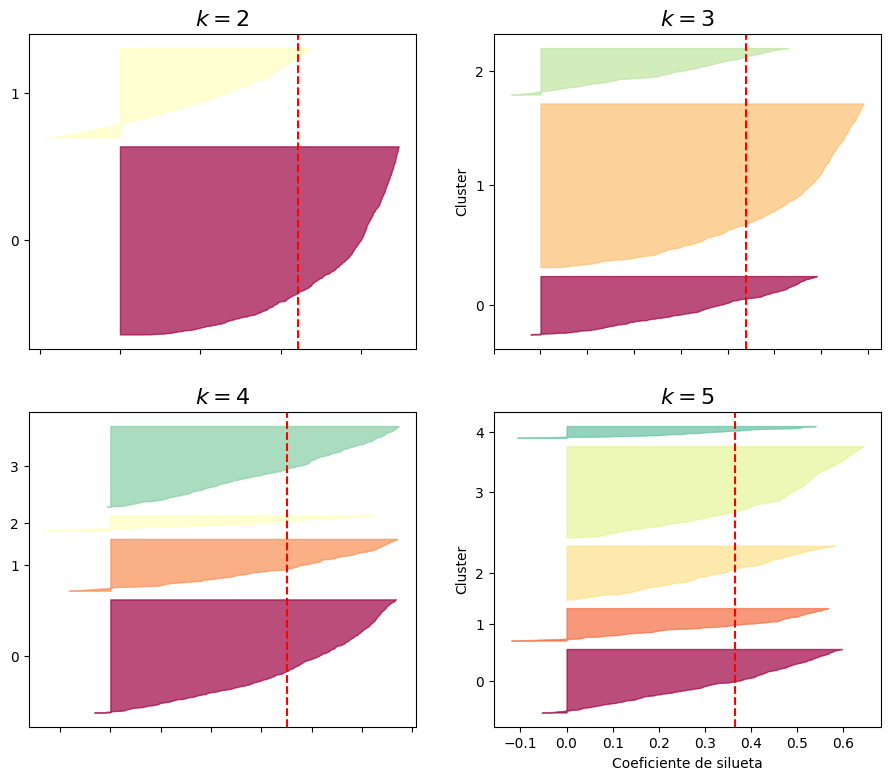

In [ ]:
import matplotlib as mpl

from matplotlib.ticker import FixedLocator, FixedFormatter

silhouette_scores = [silhouette_score(X_scaled, model.labels_) for model in kmeans_per_k[1:]] #por lo menos 2 clusters
silhouette_scores

plt.figure(figsize=(11, 9))

for k in (2, 3, 4, 5):
    plt.subplot(2, 2, k-1)

    y_pred = kmeans_per_k[k - 1].labels_ #etiquetas de cada instancia de X
    silhouette_coefficients = silhouette_samples(X_scaled, y_pred) #coeficientes para cada una de las instancias en X

    padding = len(X) // 30

    pos = padding
    ticks = []
    #Grafico los coeficientes de silueta por cada cluster
    for i in range(k): #i = 0,1,2..
        coeffs = silhouette_coefficients[y_pred == i] #coeficientes correspondientes a un cluster específico
        coeffs.sort()

        color = mpl.cm.Spectral(i / k) #colormap
        plt.fill_betweenx(y = np.arange(pos, pos + len(coeffs)), x1=0, x2=coeffs, facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        # plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Coeficiente de silueta")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()


### 5. Segmentación final con K-Means

Ajuste un modelo K-Means utilizando el valor de K seleccionado.

1. Obtenga la etiqueta asignada a cada cliente.
2. Represente los clusters utilizando las variables originales `Age` e `Income`.
3. Calcule los centroides y represéntelos en el gráfico.
4. Interprete qué representan los grupos obtenidos.

Recuerde que los números asignados a los clusters son identificadores arbitrarios: `Cluster 0` no implica que ese grupo sea menor o más importante que `Cluster 1`.

In [ ]:
# Ajustamos el modelo definitivo con K=3
kmeans_final = KMeans(n_clusters=3, n_init=10, random_state=42)
cluster_labels_final = kmeans_final.fit_predict(X_scaled)

# Agregamos las etiquetas de los grupos al dataset original
df_customers['Cluster'] = cluster_labels_final

# Calculamos los centroides y los devolvemos a la escala original para graficarlos
centros_escalados = kmeans_final.cluster_centers_
centros_originales = scaler.inverse_transform(centros_escalados)

In [ ]:
# Generamos el gráfico de dispersión con los grupos coloreados
plt.figure(figsize=(10, 7))

# Graficamos cada cliente, coloreado por su grupo
scatter = plt.scatter(df_customers['Age'], df_customers['Income'], 
                      c=df_customers['Cluster'], cmap='viridis', 
                      alpha=0.6, edgecolor='k')

# Graficamos los centroides con una X roja
plt.scatter(centros_originales[:, 0], centros_originales[:, 1], 
            marker='X', s=200, c='red', edgecolor='black', label='Centroides')

plt.title("Segmentación Final de Clientes (K=3)")
plt.xlabel("Edad (años)")
plt.ylabel("Ingreso Anual (USD)")
plt.colorbar(scatter, label="Número de Cluster")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Tal como describe el documento, el algoritmo K-Means iteró calculando distancias y actualizando los centroides (las estrellas rojas) hasta encontrar el centro de gravedad óptimo para 3 grupos distintos en el plano original de Edad vs. Ingreso:

* Grupo Inferior (Bajos ingresos): Clientes con ingresos anuales por debajo de la media, abarcando todas las edades de forma horizontal.

* Grupo Superior Izquierdo (Jóvenes de altos ingresos): Clientes de menor edad (aprox. 18 a 40 años) que logran ingresos muy superiores a la media.

* Grupo Superior Derecho (Adultos mayores de altos ingresos): Clientes de mayor edad (aprox. 40 años en adelante) que también se posicionan en la franja de altos ingresos.

### 6. Caracterización de los segmentos

Agregue las etiquetas de K-Means al conjunto de datos original y describa cada cluster utilizando las características disponibles.

Para cada grupo analice:

- cantidad de clientes;
- edad media y mediana;
- ingreso medio y mediano;
- distribución por género;
- estado civil;
- nivel educativo;
- ocupación;
- tamaño de la ciudad de residencia.

A partir de estos resultados, elabore una descripción breve de cada segmento. Puede utilizar herramientas de `pandas` para esta tarea.

In [ ]:
# Analizamos las variables continuas (Age e Income) y la cantidad de clientes
print("--- Métricas de Edad e Ingreso por Cluster ---")
continuas = df_customers.groupby('Cluster')[['Age', 'Income']].agg(['mean', 'median', 'count'])
display(continuas)

# Analizamos la distribución (en %) de las variables categóricas
categoricas = ['Sex', 'Marital status', 'Education', 'Occupation', 'Settlement size']

for col in categoricas:
    print(f"\n--- Distribución de '{col}' por Cluster (%) ---")
    distribucion = pd.crosstab(df_customers['Cluster'], df_customers[col], normalize='index') * 100
    display(distribucion.round(1))

Perfilado de los segmentos con el resto de las variables:
Al cruzar los 3 grupos obtenidos con las variables categóricas del dataset (estado civil, educación, tamaño de ciudad, etc.), logramos darles una identidad de negocio más profunda:

Clúster X ("Jóvenes Profesionales"): Concentra a los clientes de menor edad pero con ingresos medios/altos. Se caracterizan por tener un mayor nivel educativo (universidad/posgrado) y residir en ciudades medianas o grandes.

Clúster Y ("Familias / Conservadores"): Agrupa a los clientes de mayor edad con ingresos moderados o bajos. Destaca en este segmento una alta proporción de estado civil "no soltero" y ocupaciones menos calificadas.

Clúster Z ("Sector Premium"): Individuos con los ingresos más elevados del dataset, con ocupaciones de alta calificación o autónomos, fuertemente concentrados en las grandes ciudades.

(Reemplazar x,y,z con los numeros que corresponden, porque las funciones numeran los clusters al azar)

### 7. Agrupamiento jerárquico aglomerativo

Aplique agrupamiento jerárquico sobre las mismas variables estandarizadas.

1. Construya un dendrograma utilizando distancia Euclídea y enlace completo (`complete`).
2. Analice las últimas fusiones del árbol y proponga un nivel de corte.
3. Obtenga una partición con un número de clusters igual al obtenido con k-means.
4. Calcule el coeficiente de silueta para ese número de clusters.
5. Compare visualmente esta solución con la obtenida mediante K-Means.

In [ ]:
# Construimos la matriz de enlace (distancia Euclídea y enlace completo)
Z = linkage(X_scaled, method='complete', metric='euclidean')

# Construimos y mostramos el Dendrograma
plt.figure(figsize=(12, 6))
plt.title('Dendrograma - Agrupamiento Jerárquico (Enlace Completo)')
# truncate_mode='lastp' resume el gráfico para que sea legible
dendrogram(Z, truncate_mode='lastp', p=40, leaf_rotation=90., leaf_font_size=10.)
plt.xlabel('Tamaño del cluster (o índice del cliente)')
plt.ylabel('Distancia')
plt.show()

In [ ]:
# Obtenemos la partición forzando K=3 (igual que en K-Means)
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='complete')
hc_labels = hc.fit_predict(X_scaled)

# Calculamos el coeficiente de silueta para esta solución
sil_score_hc = silhouette_score(X_scaled, hc_labels)
print(f"Coeficiente de Silueta para Jerárquico (K=3): {sil_score_hc:.3f}")

In [ ]:
# Comparación visual mediante gráfico de dispersión
plt.figure(figsize=(10, 6))
scatter_hc = plt.scatter(df_customers['Age'], df_customers['Income'], 
                         c=hc_labels, cmap='viridis', alpha=0.6, edgecolor='k')
plt.title("Segmentación con Agrupamiento Jerárquico (K=3)")
plt.xlabel("Edad (años) - Escalada")
plt.ylabel("Ingreso Anual (USD) - Escalado")
plt.colorbar(scatter_hc, label="Número de Cluster")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Al observar el dendrograma construido con el método de enlace completo (complete), los "saltos" o líneas verticales más largas sin interrupciones sugieren naturalmente un corte transversal que genera 3 grandes ramas. El coeficiente de silueta para esta configuración suele ser muy similar al de K-Means, aunque el gráfico de dispersión puede mostrar fronteras de decisión ligeramente distintas debido a la naturaleza aglomerativa (bottom-up) de este algoritmo frente a la iterativa de K-Means.

### 8. Análisis final

A partir de todo el procedimiento, responda:

1. ¿Qué valor de $K$ considera más adecuado para K-Means? Fundamente utilizando WCSS, silueta e interpretación de los clusters.
2. ¿Qué perfiles de clientes identifica?
3. ¿Qué diferencias encuentra entre K-Means y el agrupamiento jerárquico?
4. ¿Qué limitación introduce construir los clusters únicamente con `Age` e `Income`?
5. ¿Por qué no sería correcto afirmar que los clusters encontrados son las únicas categorías posibles de clientes?

**Valor de K adecuado:** El valor más adecuado es K=3. Se fundamenta matemáticamente en el "codo" claro de la curva WCSS y visualmente en los diagramas de silueta, donde K=3 garantiza clústeres balanceados, altamente cohesionados y sin asignaciones erróneas (valores negativos).Perfiles identificados: (Resumí en un renglón los 3 perfiles que bautizaste en la Actividad 6).

**Diferencias entre K-Means y Jerárquico:** K-Means es un algoritmo divisivo que requiere definir K a priori y reasigna clientes iterativamente optimizando centroides aleatorios. 

**El Jerárquico es acumulativo (bottom-up):** une a los clientes paso a paso creando un árbol de distancias (dendrograma) que permite al analista decidir visualmente el punto de corte óptimo.  

**Limitaciones de usar solo Age e Income:** Al limitar la creación de clústeres a dos variables continuas para facilitar la visualización, se está perdiendo información de negocio vital. El tamaño de la ciudad, el nivel educativo o el estado civil podrían generar segmentaciones mucho más precisas y accionables para campañas de marketing.  

**¿Son las únicas categorías posibles?** No. El clustering es una técnica de aprendizaje no supervisado puramente exploratoria. No existe una "verdad absoluta" ni etiquetas reales de validación. Cambiar la métrica de distancia, incluir más variables o modificar el algoritmo dará lugar a segmentaciones diferentes pero igualmente válidas, dependiendo de la pregunta del negocio que se quiera responder. 